In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv(r"C:\Users\win10\OneDrive\Desktop\Data-Projects\Portfolio Project\Credit Card Fraud Detection\01_Data\creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

No missing values found.

Dataset is clean and ready for analysis.

Fraud Percentage: 0.1727%


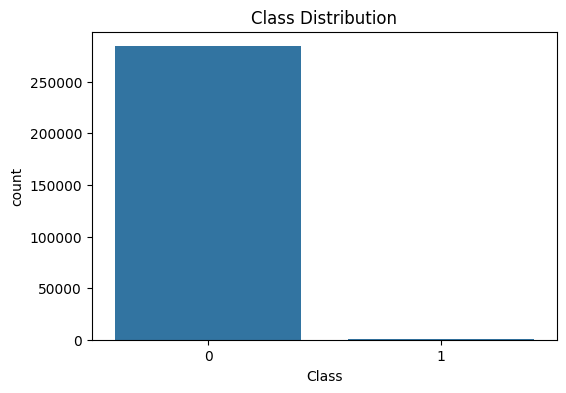

In [7]:
# CLASS DISTRIBUTION 
df['Class'].value_counts()
fraud_percentage = round(df['Class'].mean() * 100, 4)
print(f"Fraud Percentage: {fraud_percentage}%")

plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution")
plt.show()

The dataset is highly imbalanced.

Fraudulent transactions account for less than 1% of total transactions.
This imbalance requires specialized handling during model training.

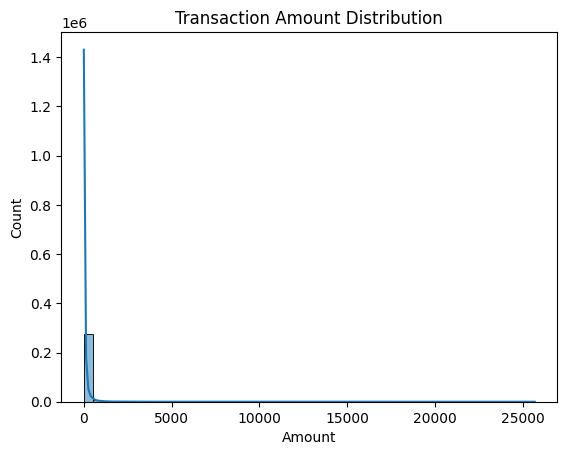

In [8]:
#TRANSACTION AMOUNT ANALYSIS

plt.Figure(figsize=(10,5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

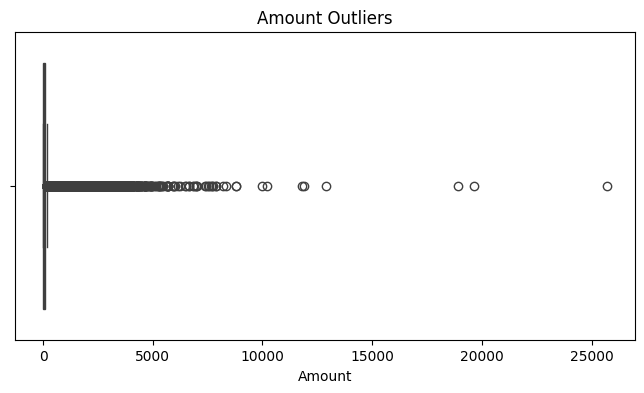

In [9]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Amount'])
plt.title("Amount Outliers")
plt.show()

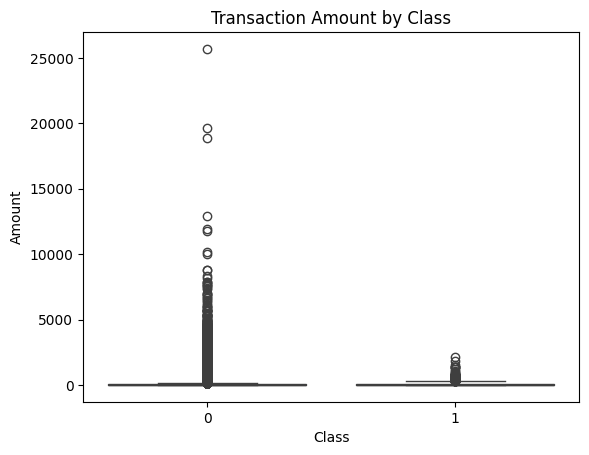

In [10]:
# FRAUD VS NON-FRAUD AMOUNT

plt.Figure(figsize=(10,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Transaction Amount by Class")
plt.show()

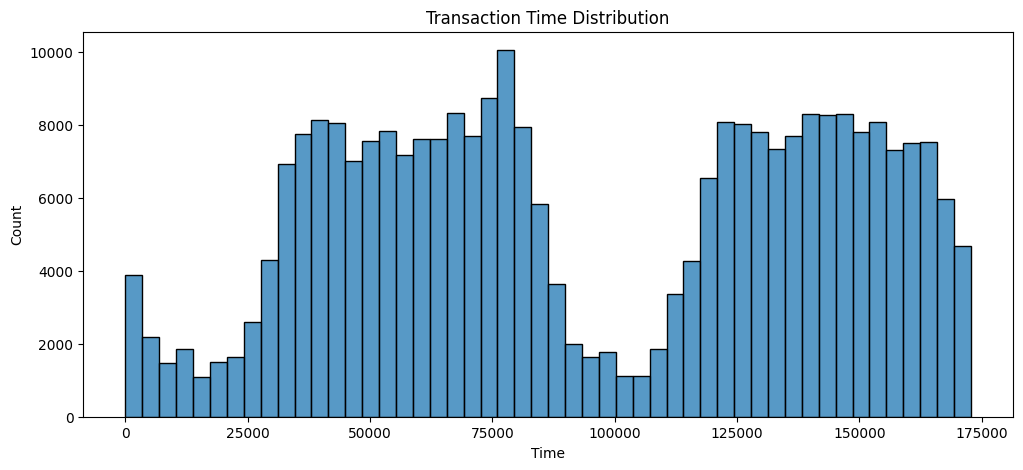

In [11]:
# TIME FEATURE ANALYSIS

plt.figure(figsize=(12,5))
sns.histplot(df['Time'], bins=50)
plt.title("Transaction Time Distribution")
plt.show()

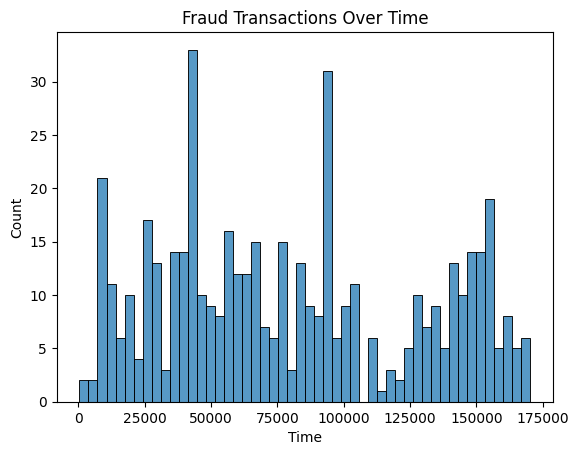

In [12]:
# FRAUD ACROSS TIME

fraud_df = df[df['Class']==1]
plt.Figure(figsize=(12,5))
sns.histplot(fraud_df['Time'], bins=50)
plt.title("Fraud Transactions Over Time")
plt.show()

Fraudulent transactions occur throughout the observation period,
suggesting no obvious temporal concentration.

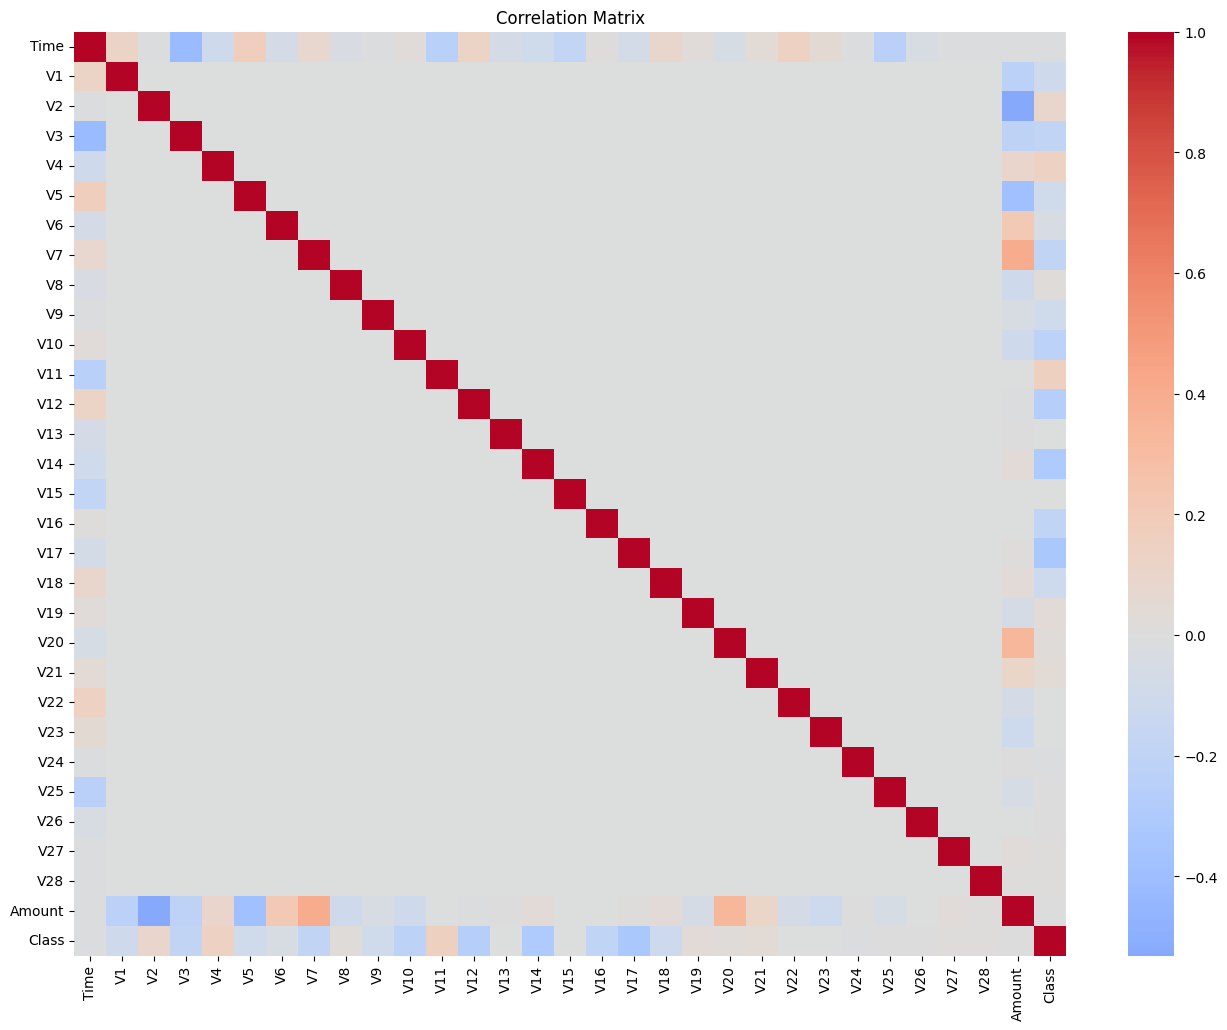

In [13]:
# CORRELATION   

plt.figure(figsize=(16,12))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

In [14]:
corr_target = (df.corr()['Class'].sort_values(ascending=False))
corr_target

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

In [15]:
print(corr_target.head(10))
print(corr_target.tail(10))

Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64
V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


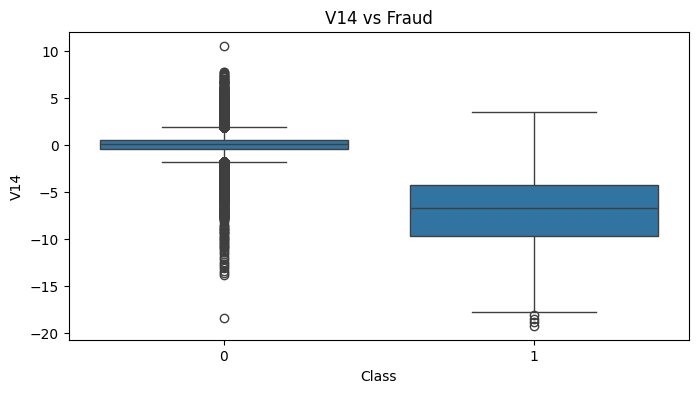

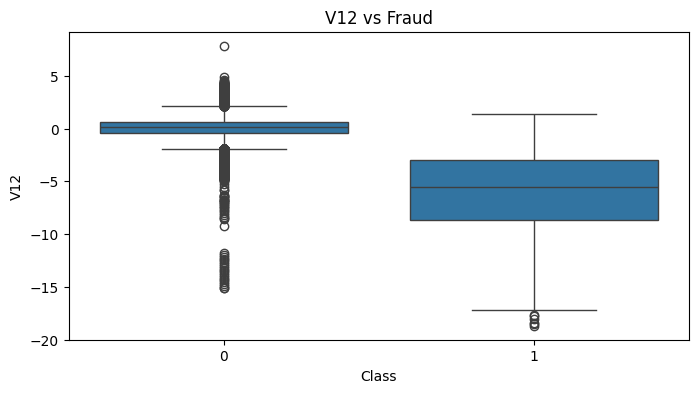

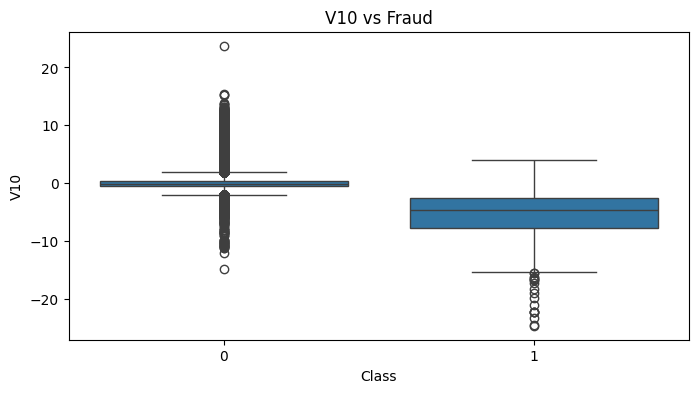

In [16]:
# TOP FRAUD FEATURES VISUALIZATION

top_features = ['V14','V12','V10']

for feature in top_features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='Class', y=feature, data=df)
    plt.title(f"{feature} vs Fraud")
    plt.show()

Feature behavior differs significantly between fraud and non-fraud transactions.

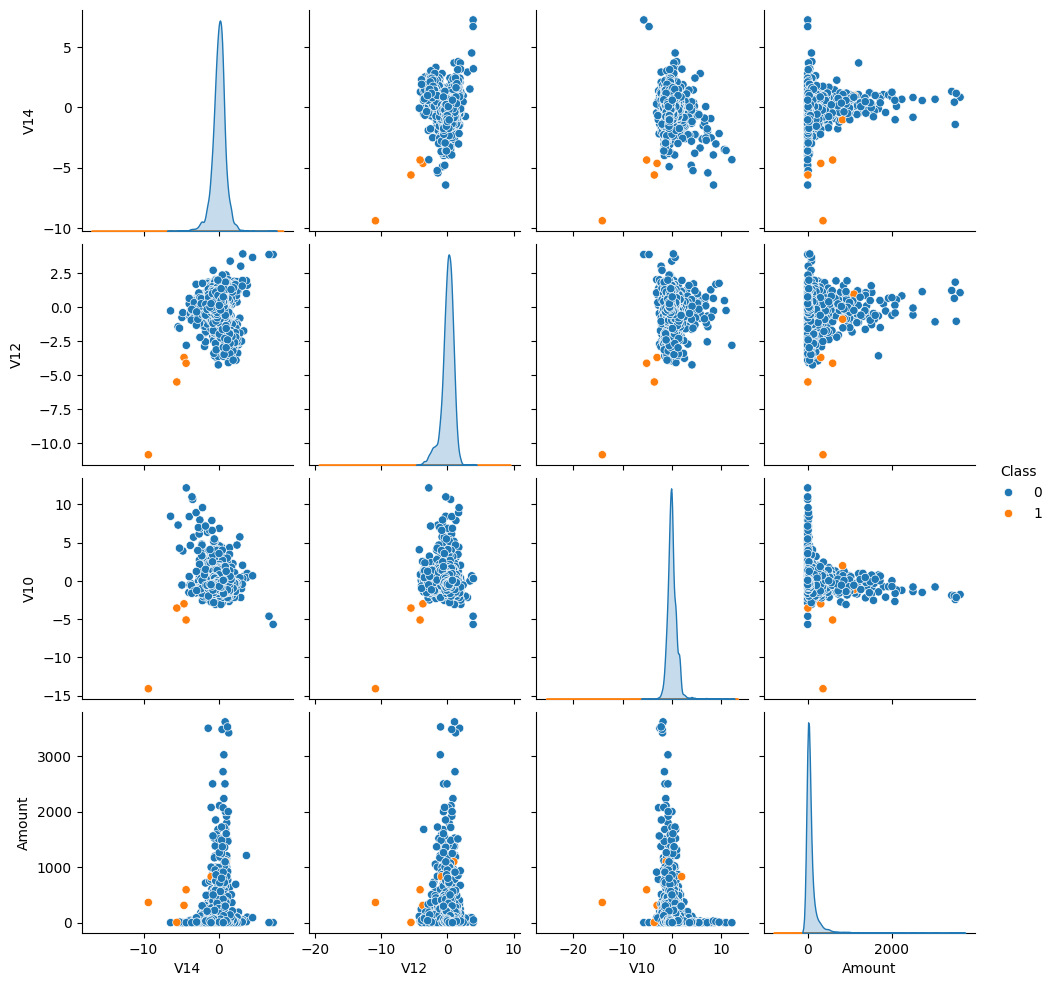

In [17]:
# Pairplot (Sample Only)
# Dataset is huge.

sample = df.sample(5000, random_state=42)
selected_features = ['V14','V12','V10','Amount','Class']
sns.pairplot(sample[selected_features], hue="Class")

# EDA Conclusions

1. Dataset contains 284,807 transactions.

2. Fraud cases account for only 0.17% of records.

3. No missing values are present.

4. Transaction amount is highly skewed.

5. Several PCA-transformed features
   show strong correlation with fraud.

6. Significant class imbalance exists,
   requiring techniques such as SMOTE.

7. Fraud detection should prioritize Recall
   while maintaining acceptable Precision.